In [5]:
pip install -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install langchain-ollama


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install langchain-ollama


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from langgraph.graph import StateGraph
from langchain_ollama import ChatOllama
from langgraph.graph.message import MessagesState

In [18]:
from langgraph.graph import StateGraph,START,END

In [15]:
model = ChatOllama(model="llama3.1:8b")

In [16]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [19]:
builder=StateGraph(MessagesState)
builder.add_node(call_model,'call_model')
builder.add_edge(START,"call_model")
builder.add_edge("call_model",END)

In [20]:
graph=builder.compile()

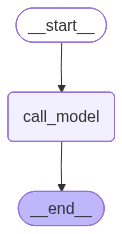

In [21]:
graph

In [23]:
graph.invoke({'messages':[{'role':'user','content':'hi my name is rakesh'}]})

{'messages': [HumanMessage(content='hi my name is rakesh', additional_kwargs={}, response_metadata={}, id='38da8a22-6f75-40d5-8d01-3af7e54f9008'),
  AIMessage(content="Hello Rakesh! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-13T06:12:40.11934Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9573444542, 'load_duration': 7650184334, 'prompt_eval_count': 17, 'prompt_eval_duration': 244310042, 'eval_count': 28, 'eval_duration': 1655202792, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ebf9c-46cd-7113-a6a0-bdfcfc88f6f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 28, 'total_tokens': 45})]}

In [24]:
graph.invoke({"messages":[{'role':'user','content':"What is my name plz help me "}]})

{'messages': [HumanMessage(content='What is my name plz help me ', additional_kwargs={}, response_metadata={}, id='f7b76612-7679-419e-b13e-3fd7cf01c3c4'),
  AIMessage(content="I'd be happy to try and help you figure out your name. However, I'm a large language model, I don't have the ability to know or recall any personal information about individual users.\n\nCould you give me some hints or clues that might help me guess your name? For example:\n\n* Do you remember anything from childhood that might be associated with your name?\n* Is there a family member or loved one who shares a similar name with you?\n* Are you named after someone famous or significant to you?\n* Do you have any distinctive initials or birthmarks that might give away your name?\n\nAny information you can provide will help me try to make an educated guess!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-13T06:13:50.140105Z', 'done': True, 'done_reason': 'stop', 'total_durat

In [25]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)

In [28]:
config1={'configurable':{'thread_id':'thread_1'}}
config2={'configurable':{'thread_id':'thread_2'}}

In [31]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Trump"}]}, config1) 

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='8f08a99f-296e-47d1-bba7-7ea9c7fba100'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-13T06:53:46.833461Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5407461708, 'load_duration': 3720735666, 'prompt_eval_count': 18, 'prompt_eval_duration': 225754042, 'eval_count': 27, 'eval_duration': 1451528165, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ebfc1-faac-75a1-a668-3aa3c8383556-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 27, 'total_tokens': 45}),
  HumanMessage(content='what is my name ', additional_kwargs={}, response_metadata={}, id='0532e154-e167-490e-b91a-c524133ab99e'),
  AIMessage(content='Your name is N

In [32]:
graph.invoke({"messages": [{"role": "user", "content": "what is my name "
""}]}, config1) 

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='8f08a99f-296e-47d1-bba7-7ea9c7fba100'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-13T06:53:46.833461Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5407461708, 'load_duration': 3720735666, 'prompt_eval_count': 18, 'prompt_eval_duration': 225754042, 'eval_count': 27, 'eval_duration': 1451528165, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ebfc1-faac-75a1-a668-3aa3c8383556-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 27, 'total_tokens': 45}),
  HumanMessage(content='what is my name ', additional_kwargs={}, response_metadata={}, id='0532e154-e167-490e-b91a-c524133ab99e'),
  AIMessage(content='Your name is N

snap=graph.get_state(config1)
v=snap.values
for m in v.get('messages',[]):
    print(m.content)


{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='8f08a99f-296e-47d1-bba7-7ea9c7fba100'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-13T06:53:46.833461Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5407461708, 'load_duration': 3720735666, 'prompt_eval_count': 18, 'prompt_eval_duration': 225754042, 'eval_count': 27, 'eval_duration': 1451528165, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ebfc1-faac-75a1-a668-3aa3c8383556-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 27, 'total_tokens': 45}),
  HumanMessage(content='what is my name ', additional_kwargs={}, response_metadata={}, id='0532e154-e167-490e-b91a-c524133ab99e'),
  AIMessage(content='Your name is N